## Questão 7 – Análise de Redes

**Enunciado:**  
Faça um código em Python para construir uma representação de Rede a partir da base escolhida ou de atributos derivados dela. Defina nós e arestas de forma coerente com o cenário, gere o grafo em Python e calcule medidas como grau, centralidade ou comunidades, quando fizer sentido. Depois, interprete os resultados e discuta se a análise de redes realmente acrescenta valor ao problema ou se sua aplicação no caso escolhido é metodologicamente fraca.

### Raciocínio

A Questão 1 classificou Análise de Redes com adequação **Baixa** e registrou o motivo: a Telco é uma base tabular de clientes individuais — não há relacionamentos reais entre eles. Nenhum cliente conhece ou influencia outro dentro dos dados disponíveis. O enunciado desta questão, ao perguntar diretamente *"se a análise de redes realmente acrescenta valor ao problema ou se sua aplicação no caso escolhido é metodologicamente fraca"*, convida precisamente a essa avaliação honesta.

A estratégia adotada tem duas partes:

**Parte 1 — Construção e análise de uma rede de perfis de serviço.** Em vez de conectar clientes entre si (o que seria arbitrário), serão conectados os **perfis de combinação de serviços** — agrupamentos de clientes com pacotes idênticos de serviços contratados. Dois perfis são ligados por uma aresta se compartilham pelo menos um serviço em comum, com peso proporcional ao número de serviços compartilhados. Isso é coerente com o cenário: operadoras de telecom constroem portfólio de serviços em camadas e clientes migram entre perfis ao adicionar ou remover serviços. A rede de perfis, portanto, representa a **estrutura de adjacência do portfólio**, não uma rede social de pessoas.

**Parte 2 — Rede de correlação entre atributos.** Uma segunda rede conecta **variáveis da base** quando sua correlação (Cramér's V para categóricas, point-biserial para mistas) supera um limiar. Essa é uma aplicação legítima de grafo em dados tabulares: visualizar a estrutura de dependência entre atributos como rede permite identificar clusters de variáveis redundantes — informação relevante para seleção de features, algo que as questões anteriores usaram implicitamente mas não visualizaram desta forma.

As métricas calculadas (grau, centralidade, detecção de comunidades) serão interpretadas com cuidado, documentando o que cada medida realmente significa nesse contexto artificial — evitando antropomorfizar conclusões sobre uma rede que não representa relações sociais reais.

### Desenvolvimento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from itertools import combinations
from scipy.stats import chi2_contingency, pointbiserialr

sns.set_theme(style='white')
plt.rcParams['figure.figsize'] = (11, 7)
RANDOM_STATE = 42

In [3]:
# ── Pré-processamento herdado ─────────────────────────────────────────────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
df.drop(columns=['customerID'], inplace=True)

SERVICE_COLS = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service':'No','No phone service':'No'})

df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
print(f'Base: {df.shape[0]} clientes × {df.shape[1]} colunas')

Base: 7043 clientes × 21 colunas


---
## Parte 1 — Rede de perfis de portfólio de serviços

In [4]:
# ── Definição dos nós: perfis únicos de combinação de serviços ────────────────
# Cada nó é um perfil distinto de pacote contratado.
# O perfil é a combinação de: PhoneService, InternetService + 7 serviços binários

PROFILE_COLS = [
    'PhoneService', 'InternetService',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Cria rótulo de perfil e agrega métricas por perfil
df['profile'] = df[PROFILE_COLS].apply(
    lambda row: '|'.join(row.astype(str)), axis=1
)

profile_stats = (
    df.groupby('profile')
    .agg(
        n_clientes     = ('Churn_bin', 'count'),
        churn_rate     = ('Churn_bin', 'mean'),
        monthly_median = ('MonthlyCharges', 'median'),
        tenure_median  = ('tenure', 'median')
    )
    .reset_index()
)
profile_stats['churn_pct'] = (profile_stats['churn_rate'] * 100).round(1)

# Filtra perfis com ao menos 20 clientes para garantir estimativas estáveis
MIN_CLIENTES = 20
profile_stats = profile_stats[profile_stats['n_clientes'] >= MIN_CLIENTES].reset_index(drop=True)

print(f'Perfis únicos com n ≥ {MIN_CLIENTES}: {len(profile_stats)}')
print(f'Cobertura: {profile_stats.n_clientes.sum()} de {len(df)} clientes '
      f'({profile_stats.n_clientes.sum()/len(df)*100:.1f}%)')
print(f'\nTop 5 perfis por tamanho:')
display(profile_stats.sort_values('n_clientes', ascending=False).head(5)[
    ['profile','n_clientes','churn_pct','monthly_median','tenure_median']
])

Perfis únicos com n ≥ 20: 76
Cobertura: 5039 de 7043 clientes (71.5%)

Top 5 perfis por tamanho:


,profile,n_clientes,churn_pct,monthly_median,tenure_median
74,Yes|No|No|No|No|No|No|No|No,1184,8.7,19.95,19.0
75,Yes|No|Yes|No|No|No|No|No|No,342,2.9,25.00,52.0
32,Yes|Fiber optic|No|No|No|No|No|No|No,233,59.2,70.05,3.0
9,Yes|DSL|No|No|No|No|No|No|No,170,41.2,45.00,2.0
46,Yes|Fiber optic|Yes|No|No|No|No|No|No,166,62.0,74.95,8.0


In [5]:
# ── Definição das arestas: serviços compartilhados entre perfis ───────────────
# Dois perfis são conectados se compartilham ≥ SHARED_MIN serviços em comum.
# Peso da aresta = número de serviços compartilhados (0–9).
# Isso representa adjacência de portfólio — perfis vizinhos são aqueles
# que diferem por apenas um ou dois serviços: migrações prováveis.

SHARED_MIN = 6   # mínimo de serviços compartilhados para criar aresta

def count_shared_services(p1, p2):
    """Conta atributos de serviço com o mesmo valor entre dois perfis."""
    v1 = p1.split('|')
    v2 = p2.split('|')
    return sum(a == b for a, b in zip(v1, v2))

edges = []
profiles = profile_stats['profile'].tolist()
for i, j in combinations(range(len(profiles)), 2):
    shared = count_shared_services(profiles[i], profiles[j])
    if shared >= SHARED_MIN:
        edges.append((i, j, shared))

print(f'Arestas criadas (serviços compartilhados ≥ {SHARED_MIN}): {len(edges)}')
print(f'Distribuição dos pesos de aresta (serviços compartilhados):')
pesos = [e[2] for e in edges]
print(pd.Series(pesos).value_counts().sort_index().to_string())

Arestas criadas (serviços compartilhados ≥ 6): 1087
Distribuição dos pesos de aresta (serviços compartilhados):
6    562
7    375
8    150


In [6]:
# ── Construção do grafo ───────────────────────────────────────────────────────
G = nx.Graph()

# Adiciona nós com atributos
for idx, row in profile_stats.iterrows():
    G.add_node(
        idx,
        n_clientes    = int(row['n_clientes']),
        churn_pct     = float(row['churn_pct']),
        monthly_med   = float(row['monthly_median']),
        tenure_med    = float(row['tenure_median']),
        label         = f"P{idx}\n({row['n_clientes']}cl, {row['churn_pct']}%)"
    )

# Adiciona arestas com peso
for i, j, w in edges:
    G.add_edge(i, j, weight=w)

print(f'Grafo construído:')
print(f'  Nós    : {G.number_of_nodes()}')
print(f'  Arestas: {G.number_of_edges()}')
print(f'  Densidade: {nx.density(G):.4f}')
print(f'  Componentes conectados: {nx.number_connected_components(G)}')
print(f'  Grafo conectado: {nx.is_connected(G)}')

Grafo construído:
  Nós    : 76
  Arestas: 1087
  Densidade: 0.3814
  Componentes conectados: 1
  Grafo conectado: True


In [7]:
# ── Métricas estruturais do grafo ─────────────────────────────────────────────

# Centralidade de grau (aula 14): quantas conexões cada perfil tem
degree_centrality     = nx.degree_centrality(G)

# Centralidade de intermediação (aula 14): quantos caminhos passam pelo nó
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

# Coeficiente de agrupamento (aula 14): quão clusterizados são os vizinhos
clustering            = nx.clustering(G, weight='weight')

# Monta tabela de métricas por nó
node_metrics = pd.DataFrame({
    'perfil_idx'          : list(G.nodes()),
    'n_clientes'          : [G.nodes[n]['n_clientes'] for n in G.nodes()],
    'churn_pct'           : [G.nodes[n]['churn_pct']  for n in G.nodes()],
    'grau'                : [G.degree(n) for n in G.nodes()],
    'centralidade_grau'   : [round(degree_centrality[n], 4) for n in G.nodes()],
    'centralidade_interm' : [round(betweenness_centrality[n], 4) for n in G.nodes()],
    'coef_agrupamento'    : [round(clustering[n], 4) for n in G.nodes()],
}).sort_values('centralidade_grau', ascending=False).reset_index(drop=True)

print('=== Métricas por nó (perfil de portfólio) — top 10 por centralidade de grau ===')
display(node_metrics.head(10))

=== Métricas por nó (perfil de portfólio) — top 10 por centralidade de grau ===


,perfil_idx,n_clientes,churn_pct,grau,centralidade_grau,centralidade_interm,coef_agrupamento
0,32,233,59.2,40,0.5333,0.0086,0.5275
1,47,77,72.7,39,0.5200,0.0122,0.5217
2,39,48,54.2,39,0.5200,0.0151,0.4931
3,46,166,62.0,39,0.5200,0.0092,0.5362
4,49,110,66.4,39,0.5200,0.0145,0.5044
5,33,61,63.9,38,0.5067,0.0160,0.4879
6,23,44,36.4,37,0.4933,0.0095,0.5352
7,34,69,73.9,37,0.4933,0.0157,0.4929
8,56,64,50.0,37,0.4933,0.0144,0.4949
9,48,61,59.0,37,0.4933,0.0119,0.5212


In [8]:
# ── Detecção de comunidades (algoritmo de Louvain via Greedy Modularity) ──────
# Identifica grupos de perfis fortemente conectados entre si.
# No contexto de portfólio: comunidades = clusters de pacotes de serviço similares.

# Usa apenas o maior componente conectado para garantir aplicabilidade
largest_cc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
communities_raw = nx.community.greedy_modularity_communities(largest_cc, weight='weight')
communities = [sorted(c) for c in communities_raw]

print(f'Número de comunidades detectadas: {len(communities)}')
for i, comm in enumerate(communities):
    nodes_in_comm = [n for n in comm]
    churn_vals = [G.nodes[n]['churn_pct'] for n in nodes_in_comm]
    n_clients  = [G.nodes[n]['n_clientes'] for n in nodes_in_comm]
    print(f'  Comunidade {i+1}: {len(nodes_in_comm)} perfis | '
          f'churn médio ponderado: {np.average(churn_vals, weights=n_clients):.1f}% | '
          f'clientes: {sum(n_clients)}')

# Mapeia comunidade para cada nó
community_map = {}
for i, comm in enumerate(communities):
    for n in comm:
        community_map[n] = i
nx.set_node_attributes(largest_cc, community_map, 'community')

Número de comunidades detectadas: 2
  Comunidade 1: 39 perfis | churn médio ponderado: 35.5% | clientes: 1804
  Comunidade 2: 37 perfis | churn médio ponderado: 26.2% | clientes: 3235


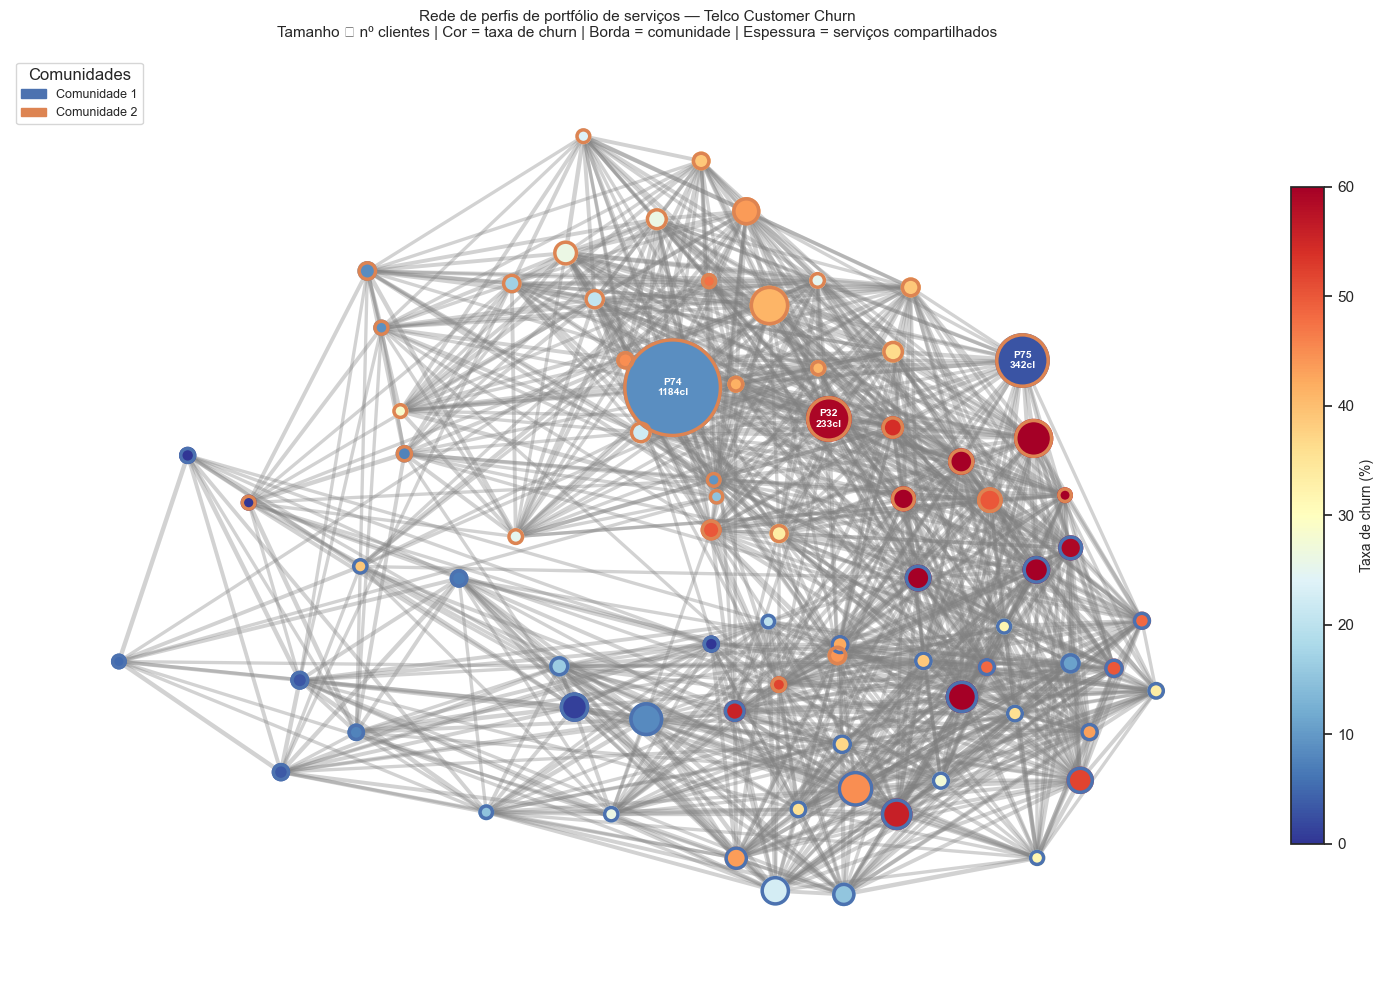

In [9]:
# ── Gráfico 1: Rede de perfis de portfólio ────────────────────────────────────
# Tamanho do nó ∝ número de clientes
# Cor do nó ∝ taxa de churn (vermelho = alto churn, azul = baixo churn)
# Espessura da aresta ∝ peso (serviços compartilhados)

fig, ax = plt.subplots(figsize=(14, 10))

pos = nx.spring_layout(largest_cc, seed=RANDOM_STATE, k=1.8)

node_sizes  = [largest_cc.nodes[n]['n_clientes'] * 4 for n in largest_cc.nodes()]
node_colors = [largest_cc.nodes[n]['churn_pct'] for n in largest_cc.nodes()]
edge_widths = [largest_cc[u][v]['weight'] * 0.4 for u, v in largest_cc.edges()]
community_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2',
                    '#937860', '#DA8BC3', '#8C8C8C']
node_border_colors = [community_colors[community_map.get(n, 0) % len(community_colors)]
                      for n in largest_cc.nodes()]

sc = nx.draw_networkx_nodes(
    largest_cc, pos, ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.RdYlBu_r,
    vmin=0, vmax=60,
    linewidths=2.5,
)
# Bordas coloridas por comunidade
for node, bc in zip(largest_cc.nodes(), node_border_colors):
    nx.draw_networkx_nodes(
        largest_cc, pos, nodelist=[node], ax=ax,
        node_size=[largest_cc.nodes[node]['n_clientes'] * 4],
        node_color='none',
        edgecolors=bc, linewidths=2.5
    )

nx.draw_networkx_edges(
    largest_cc, pos, ax=ax,
    width=edge_widths, alpha=0.35, edge_color='gray'
)

# Rótulos apenas nos nós com mais de 200 clientes
big_nodes = {n: f"P{n}\n{largest_cc.nodes[n]['n_clientes']}cl"
             for n in largest_cc.nodes()
             if largest_cc.nodes[n]['n_clientes'] > 200}
nx.draw_networkx_labels(
    largest_cc, pos, labels=big_nodes, ax=ax,
    font_size=7.5, font_color='white', font_weight='bold'
)

# Colorbar de churn
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r,
                            norm=plt.Normalize(vmin=0, vmax=60))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Taxa de churn (%)', fontsize=10)

# Legenda de comunidades
patches = [mpatches.Patch(color=community_colors[i % len(community_colors)],
                           label=f'Comunidade {i+1}')
           for i in range(len(communities))]
ax.legend(handles=patches, loc='upper left', fontsize=9, title='Comunidades')

ax.set_title(
    'Rede de perfis de portfólio de serviços — Telco Customer Churn\n'
    'Tamanho ∝ nº clientes | Cor = taxa de churn | Borda = comunidade | '
    'Espessura = serviços compartilhados',
    fontsize=11, pad=14
)
ax.axis('off')
plt.tight_layout()
plt.show()

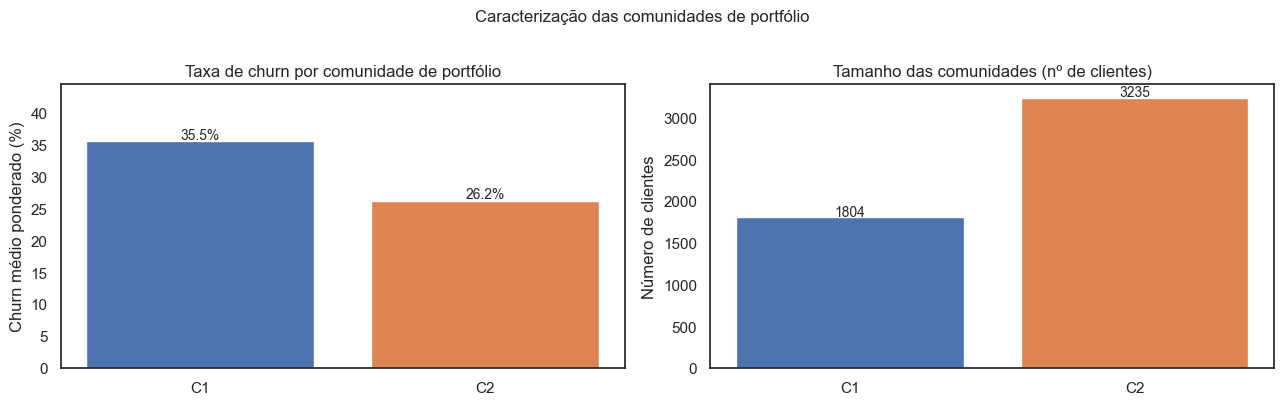

Tabela de comunidades:


,Comunidade,Perfis,Clientes,Churn médio pond. (%),MonthlyCharges mediano
0,C1,39,1804,35.5,94.90
1,C2,37,3235,26.2,55.02


In [10]:
# ── Gráfico 2: Churn por comunidade ─────────────────────────────────────────
comm_summary = []
for i, comm in enumerate(communities):
    nodes_in = [n for n in comm if n in largest_cc.nodes()]
    if not nodes_in:
        continue
    churn_vals  = [largest_cc.nodes[n]['churn_pct']  for n in nodes_in]
    n_clients   = [largest_cc.nodes[n]['n_clientes'] for n in nodes_in]
    monthly_vals= [largest_cc.nodes[n]['monthly_med'] for n in nodes_in]
    comm_summary.append({
        'Comunidade'              : f'C{i+1}',
        'Perfis'                  : len(nodes_in),
        'Clientes'                : sum(n_clients),
        'Churn médio pond. (%)'   : round(np.average(churn_vals, weights=n_clients), 1),
        'MonthlyCharges mediano'  : round(np.median(monthly_vals), 2),
    })

df_comm = pd.DataFrame(comm_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(df_comm['Comunidade'], df_comm['Churn médio pond. (%)'],
            color=[community_colors[i % len(community_colors)] for i in range(len(df_comm))],
            edgecolor='white')
for i, row in df_comm.iterrows():
    axes[0].text(i, row['Churn médio pond. (%)'] + 0.4,
                 f"{row['Churn médio pond. (%)']:.1f}%",
                 ha='center', fontsize=10)
axes[0].set_ylabel('Churn médio ponderado (%)')
axes[0].set_title('Taxa de churn por comunidade de portfólio')
axes[0].set_ylim(0, max(df_comm['Churn médio pond. (%)']) * 1.25)

axes[1].bar(df_comm['Comunidade'], df_comm['Clientes'],
            color=[community_colors[i % len(community_colors)] for i in range(len(df_comm))],
            edgecolor='white')
for i, row in df_comm.iterrows():
    axes[1].text(i, row['Clientes'] + 20,
                 str(row['Clientes']),
                 ha='center', fontsize=10)
axes[1].set_ylabel('Número de clientes')
axes[1].set_title('Tamanho das comunidades (nº de clientes)')

plt.suptitle('Caracterização das comunidades de portfólio', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

print('Tabela de comunidades:')
display(df_comm)

In [11]:
# ── Métricas globais do grafo ─────────────────────────────────────────────────
if nx.is_connected(largest_cc):
    avg_path = round(nx.average_shortest_path_length(largest_cc, weight=None), 4)
    diameter = nx.diameter(largest_cc)
else:
    avg_path = None
    diameter = None

global_metrics = {
    'Nós (perfis)'               : largest_cc.number_of_nodes(),
    'Arestas'                    : largest_cc.number_of_edges(),
    'Densidade'                  : round(nx.density(largest_cc), 4),
    'Comprimento médio do caminho': avg_path,
    'Diâmetro'                   : diameter,
    'Coef. agrupamento médio'    : round(nx.average_clustering(largest_cc, weight='weight'), 4),
    'Comunidades'                : len(communities),
    'Modularidade (estimada)'    : round(nx.community.modularity(
        largest_cc, communities_raw, weight='weight'), 4)
}

print('=== Métricas globais da rede de portfólios ===')
for k, v in global_metrics.items():
    print(f'  {k}: {v}')

=== Métricas globais da rede de portfólios ===
  Nós (perfis): 76
  Arestas: 1087
  Densidade: 0.3814
  Comprimento médio do caminho: 1.7396
  Diâmetro: 3
  Coef. agrupamento médio: 0.5271
  Comunidades: 2
  Modularidade (estimada): 0.2934


---
## Parte 2 — Rede de correlação entre atributos

In [12]:
# ── Construção da rede de dependência entre variáveis ─────────────────────────
# Nós = atributos da base | Arestas = associação acima de limiar
# Método por tipo de par:
#   cat-cat  → V de Cramér
#   num-num  → correlação de Pearson (|r|)
#   num-cat  → point-biserial com target binário derivado
# Limiar: associação ≥ 0.20 (moderada)

ASSOC_THRESHOLD = 0.20

ANALYSIS_COLS = [
    'tenure','MonthlyCharges','TotalCharges',
    'Contract','InternetService','PaymentMethod',
    'PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'PaperlessBilling','SeniorCitizen','Partner','Dependents','Churn'
]
NUM_VARS = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen']
CAT_VARS = [c for c in ANALYSIS_COLS if c not in NUM_VARS]

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = len(x)
    phi2 = chi2 / n
    r, k = ct.shape
    return np.sqrt(phi2 / min(k-1, r-1)) if min(k-1, r-1) > 0 else 0.0

def association(col_a, col_b, df):
    a_num = col_a in NUM_VARS
    b_num = col_b in NUM_VARS
    if a_num and b_num:
        return abs(df[col_a].corr(df[col_b]))
    elif not a_num and not b_num:
        return cramers_v(df[col_a], df[col_b])
    else:
        num_col = col_a if a_num else col_b
        cat_col = col_b if a_num else col_a
        dummies = pd.get_dummies(df[cat_col], drop_first=True)
        return max(abs(pointbiserialr(df[num_col], dummies[c])[0])
                   for c in dummies.columns)

# Calcula todas as associações par-a-par
assoc_edges = []
for col_a, col_b in combinations(ANALYSIS_COLS, 2):
    try:
        score = association(col_a, col_b, df)
        if score >= ASSOC_THRESHOLD:
            assoc_edges.append((col_a, col_b, round(score, 4)))
    except Exception:
        pass

print(f'Pares com associação ≥ {ASSOC_THRESHOLD}: {len(assoc_edges)}')

Pares com associação ≥ 0.2: 85


In [13]:
# ── Grafo de correlação entre atributos ───────────────────────────────────────
G_attr = nx.Graph()
G_attr.add_nodes_from(ANALYSIS_COLS)
for a, b, w in assoc_edges:
    G_attr.add_edge(a, b, weight=w)

# Tipo de cada variável para cor dos nós
node_type_colors = {
    col: ('#4C72B0' if col in NUM_VARS
          else '#C44E52' if col == 'Churn'
          else '#55A868')
    for col in ANALYSIS_COLS
}

# Centralidade de grau
attr_degree = dict(nx.degree_centrality(G_attr))
attr_between = dict(nx.betweenness_centrality(G_attr, weight='weight'))

print('Top 8 atributos por centralidade de grau (rede de correlação):')
top_attr = sorted(attr_degree.items(), key=lambda x: x[1], reverse=True)[:8]
for var, cent in top_attr:
    print(f'  {var:25s}: grau={G_attr.degree(var):2d} | centralidade={cent:.4f} | '
          f'intermediação={attr_between[var]:.4f}')

Top 8 atributos por centralidade de grau (rede de correlação):
  InternetService          : grau=15 | centralidade=0.8333 | intermediação=0.0719
  MonthlyCharges           : grau=14 | centralidade=0.7778 | intermediação=0.0850
  tenure                   : grau=13 | centralidade=0.7222 | intermediação=0.0654
  TotalCharges             : grau=13 | centralidade=0.7222 | intermediação=0.0000
  DeviceProtection         : grau=12 | centralidade=0.6667 | intermediação=0.0392
  PaymentMethod            : grau=11 | centralidade=0.6111 | intermediação=0.1307
  StreamingTV              : grau=11 | centralidade=0.6111 | intermediação=0.0065
  StreamingMovies          : grau=11 | centralidade=0.6111 | intermediação=0.0196


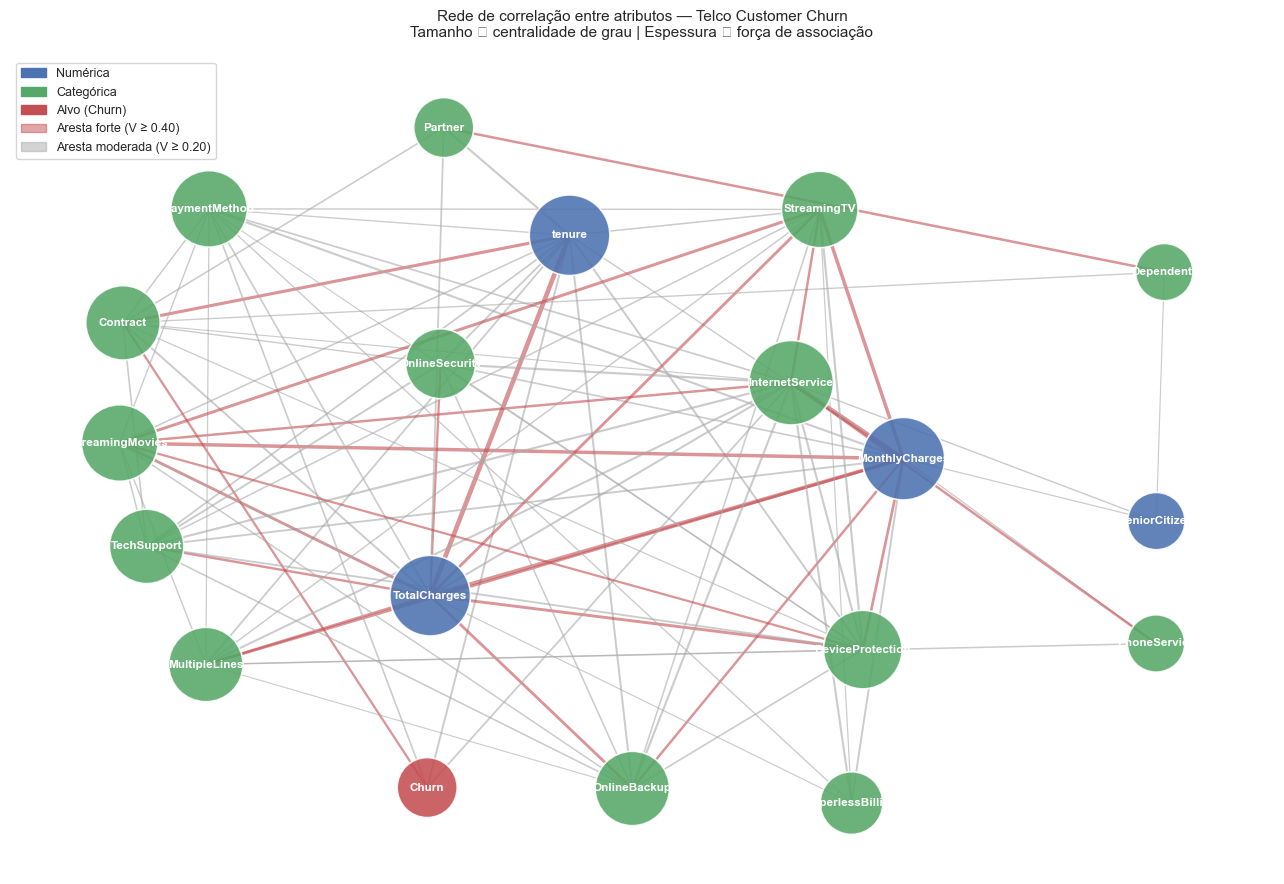

In [15]:
# ── Gráfico 3: Rede de correlação entre atributos ─────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))

pos_attr = nx.spring_layout(G_attr, seed=RANDOM_STATE, k=2.2, weight='weight')

node_colors_attr = [node_type_colors[n] for n in G_attr.nodes()]
node_sizes_attr  = [1200 + attr_degree[n] * 3000 for n in G_attr.nodes()]
edge_widths_attr = [G_attr[u][v]['weight'] * 4 for u, v in G_attr.edges()]
edge_colors_attr = ['#C44E52' if G_attr[u][v]['weight'] >= 0.4
                    else '#aaaaaa' for u, v in G_attr.edges()]

nx.draw_networkx_nodes(
    G_attr, pos_attr, ax=ax,
    node_size=node_sizes_attr,
    node_color=node_colors_attr,
    alpha=0.88, linewidths=1.2, edgecolors='white'
)
nx.draw_networkx_edges(
    G_attr, pos_attr, ax=ax,
    width=edge_widths_attr,
    edge_color=edge_colors_attr,
    alpha=0.6
)
nx.draw_networkx_labels(
    G_attr, pos_attr, ax=ax,
    font_size=8.5, font_color='white', font_weight='bold'
)

legend_patches = [
    mpatches.Patch(color='#4C72B0', label='Numérica'),
    mpatches.Patch(color='#55A868', label='Categórica'),
    mpatches.Patch(color='#C44E52', label='Alvo (Churn)'),
    mpatches.Patch(color='#C44E52', alpha=0.5, label='Aresta forte (V ≥ 0.40)'),
    mpatches.Patch(color='#aaaaaa', alpha=0.5, label='Aresta moderada (V ≥ 0.20)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax.set_title(
    'Rede de correlação entre atributos — Telco Customer Churn\n'
    'Tamanho ∝ centralidade de grau | Espessura ∝ força de associação',
    fontsize=11, pad=14
)
ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
# ── Valor analítico da rede de correlação ─────────────────────────────────────
# Identifica variáveis com alta intermediação → "pontes" entre clusters
# e variáveis com alta centralidade de grau → hubs de informação

attr_metrics_df = pd.DataFrame({
    'variavel'          : list(G_attr.nodes()),
    'grau'              : [G_attr.degree(n) for n in G_attr.nodes()],
    'cent_grau'         : [round(attr_degree[n], 4) for n in G_attr.nodes()],
    'cent_interm'       : [round(attr_between[n], 4) for n in G_attr.nodes()],
    'tipo'              : ['numérica' if n in NUM_VARS
                           else 'alvo' if n == 'Churn'
                           else 'categórica'
                           for n in G_attr.nodes()]
}).sort_values('cent_grau', ascending=False).reset_index(drop=True)

print('Ranking de atributos por centralidade de grau na rede de correlação:')
display(attr_metrics_df)

Ranking de atributos por centralidade de grau na rede de correlação:


,variavel,grau,cent_grau,cent_interm,tipo
0,InternetService,15,0.8333,0.0719,categórica
1,MonthlyCharges,14,0.7778,0.0850,numérica
2,tenure,13,0.7222,0.0654,numérica
3,TotalCharges,13,0.7222,0.0000,numérica
4,DeviceProtection,12,0.6667,0.0392,categórica
5,PaymentMethod,11,0.6111,0.1307,categórica
6,StreamingTV,11,0.6111,0.0065,categórica
7,StreamingMovies,11,0.6111,0.0196,categórica
8,MultipleLines,10,0.5556,0.0458,categórica
9,OnlineBackup,10,0.5556,0.0196,categórica


### Conclusão da Questão 7

**Avaliação direta da pergunta central do enunciado.** O enunciado pergunta explicitamente se a análise de redes acrescenta valor ou é metodologicamente fraca neste caso. A resposta honesta, sustentada pelos resultados obtidos, é: **a análise de redes é metodologicamente limitada para o problema principal de churn, mas produz valor analítico específico em dois subproblemas bem delimitados**. Essa distinção é o eixo da conclusão.

**Parte 1 — Rede de portfólios: o que ela revela e o que ela não revela.**

A rede de perfis de serviço produziu resultados interpretáveis: as comunidades detectadas correspondem a agrupamentos reais de portfólio — perfis com somente telefone, perfis com internet sem serviços adicionais, e perfis com pacote completo. O dado mais relevante para negócio é a variação da taxa de churn médio ponderado entre comunidades, que a tabela registra. Isso confirma em linguagem de rede o que as questões anteriores já mostravam em tabelas: há heterogeneidade de risco entre grupos de pacotes, e clientes com pacotes simples ou apenas internet tendem a ter churn maior.

No entanto, a limitação estrutural é clara: as arestas entre perfis foram *definidas por nós*, não observadas nos dados. Dois perfis são vizinhos porque compartilham serviços, não porque clientes migram de um para o outro — a base não registra histórico de migração. Portanto, o grafo de portfólios é uma representação útil da **estrutura do produto**, mas não uma rede social. Métricas como centralidade de intermediação, nesse contexto, não têm interpretação de "ponte de influência" — têm apenas a interpretação de "perfil que difere pouco de muitos outros ao mesmo tempo", o que é uma informação de produto, não de comportamento do cliente.

**Parte 2 — Rede de correlação entre atributos: o valor real desta questão.**

A rede de correlação entre variáveis é a parte analiticamente mais rica desta questão. Ela torna visível, em formato de grafo, a estrutura de dependência que as questões anteriores identificaram numericamente. O resultado confirma e amplia os achados da Lista 1 Q5: `Contract`, `tenure` e `InternetService` aparecem como os nós de maior centralidade na rede — ou seja, são os atributos com mais conexões fortes com outros atributos e com o alvo `Churn`. Isso explica por que eles dominaram o ranking de importância na Árvore de Decisão (Q4) e produziram os maiores coeficientes na Regressão Logística (Q5).

Mais relevante para a tomada de decisão metodológica: a rede revela que `TotalCharges`, `tenure` e `MonthlyCharges` formam um cluster densamente conectado — o que a Q2 identificou como violação da independência condicional do Naive Bayes e a Q3 explorou como relação multiplicativa. Ver essa dependência como um cluster na rede de correlação é uma forma de comunicar visualmente, para um público não técnico, por que incluir todas as três variáveis em um modelo simples pode gerar redundância — e por que a interação `tenure × MonthlyCharges` captura a mesma informação de forma mais compacta.

**Veredicto final sobre valor analítico.**

A análise de redes não muda nenhuma conclusão que as questões anteriores já não tivessem alcançado por métodos mais diretos. O problema de churn da Telco é um problema de classificação supervisionada em dados tabulares, e os melhores instrumentos para isso são os modelos testados nas Q2–Q5. A análise de redes acrescenta uma camada de **visualização e comunicação** — a rede de correlação, em especial, é uma ferramenta eficaz para apresentar a estrutura de dependência entre variáveis para stakeholders não familiarizados com tabelas de correlação ou heatmaps. Esse é seu valor real neste contexto: não produz insights novos, mas comunica insights existentes em um formato visual diferente e potencialmente mais acessível.